<a href="https://colab.research.google.com/github/moobong046/Ai/blob/main/%EC%8A%88%ED%8D%BC%EC%BD%94%EB%94%A9_1%EC%B0%A8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8%20%EB%B0%9C%ED%91%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import os
import csv
movie_path="/IMDB top 1000.csv"
data_list=[]
with open(movie_path,"r",encoding="utf-8")as f:
  reader=csv.reader(f)
  header=next(reader)
  for row in reader:
    data_list.append(row)

data_array=np.array(data_list)
title_idx=header.index("Title")
genre_idx=header.index("Genre")
rate_idx=header.index("Rate")

selected_data=data_array[:,[title_idx,genre_idx,rate_idx]]
filtered_data=selected_data[~np.any(selected_data=='',axis=1)]
print("⭐ Numpy 배열 형태의 데이터 샘플 ")
print(filtered_data[:5])


⭐ Numpy 배열 형태의 데이터 샘플 
[['1. The Shawshank Redemption (1994)' 'Drama' '9.3']
 ['2. The Godfather (1972)' 'Crime, Drama' '9.2']
 ['3. The Dark Knight (2008)' 'Action, Crime, Drama' '9.0']
 ['4. The Godfather: Part II (1974)' 'Crime, Drama' '9.0']
 ['5. The Lord of the Rings: The Return of the King (2003)'
  'Action, Adventure, Drama' '8.9']]


In [5]:
#2
x=filtered_data[:,2].astype(float)
print(f"총 영화의 개수:",filtered_data.shape[0])
print(f"평점 평균:{np.mean(x):.1f}")
print(f"최고 평점:",np.max(x))
print(f"최저 평점:",np.min(x))

총 영화의 개수: 1000
평점 평균:8.1
최고 평점: 9.3
최저 평점: 8.0


In [7]:
#3
max_rating = np.max(x)
max_rating_movie = filtered_data[x == max_rating]
print("⭐ 최고 평점 영화 목록 :")
for movie in max_rating_movie:
    print(f"{movie[0][1:]} - 평점 : {movie[2]}")

Genre_column = data_array[:, genre_idx]

all_genres = set()
for genres in Genre_column:
    all_genres.update([g.strip() for g in genres.split(',')])

⭐ 최고 평점 영화 목록 :
. The Shawshank Redemption (1994) - 평점 : 9.3


In [8]:
#4
print("⭐ 장르별 평균 평점 :")

for genre in all_genres:
    filtered_ratings = data_array[[genre in g for g in Genre_column], rate_idx].astype(float)
    average_rating = np.mean(filtered_ratings)
    print(f"{genre} : {average_rating:.1f}")


⭐ 장르별 평균 평점 :
Crime : 8.1
Sport : 8.2
Music : 8.1
Horror : 8.2
Drama : 8.1
Western : 8.4
Biography : 8.1
Adventure : 8.1
War : 8.2
Musical : 8.1
Animation : 8.1
Film-Noir : 8.1
Action : 8.1
History : 8.1
Fantasy : 8.1
Romance : 8.1
Comedy : 8.1
Sci-Fi : 8.1
Thriller : 8.1
Mystery : 8.1
Family : 8.2


In [9]:
year_dict = {}
for movie in filtered_data:
    year = movie[0][-5:-1]
    if year not in year_dict:
        year_dict[year] = []
    year_dict[year].append(float(movie[2]))

year_avg_ratings = {year: np.mean(rates) for year, rates in year_dict.items()}
sorted_years = sorted(year_avg_ratings.items(), key=lambda x: int(x[0]))
print("⭐ 연도별 평균 평점 :")
for year, avg_rating in sorted_years:
    print(f"{year}: {avg_rating:.1f}")


⭐ 연도별 평균 평점 :
1920: 8.1
1921: 8.3
1924: 8.2
1925: 8.2
1926: 8.1
1927: 8.1
1928: 8.1
1931: 8.4
1934: 8.1
1936: 8.5
1937: 8.1
1939: 8.1
1940: 8.1
1941: 8.3
1942: 8.3
1944: 8.3
1946: 8.6
1948: 8.1
1949: 8.1
1950: 8.3
1951: 8.1
1952: 8.3
1953: 8.1
1954: 8.2
1955: 8.2
1957: 8.2
1958: 8.2
1959: 8.2
1960: 8.2
1961: 8.2
1962: 8.2
1963: 8.3
1964: 8.4
1965: 8.3
1966: 8.3
1967: 8.1
1968: 8.4
1971: 8.4
1972: 8.5
1973: 8.2
1974: 8.6
1975: 8.3
1976: 8.2
1977: 8.6
1978: 8.1
1979: 8.3
1980: 8.3
1981: 8.4
1982: 8.1
1983: 8.3
1984: 8.2
1985: 8.3
1986: 8.2
1987: 8.2
1988: 8.3
1989: 8.1
1990: 8.7
1991: 8.1
1992: 8.0
1993: 8.0
1994: 8.6
1995: 8.1
1996: 8.0
1997: 8.1
1998: 8.1
1999: 8.1
2000: 8.1
2001: 8.1
2002: 8.2
2003: 8.0
2004: 8.0
2005: 8.1
2006: 8.1
2007: 8.0
2008: 8.1
2009: 8.0
2010: 8.1
2011: 8.1
2012: 8.1
2013: 8.0
2014: 8.1
2015: 8.0
2016: 8.0
2017: 8.1
2018: 8.1
2019: 8.1
2020: 8.7


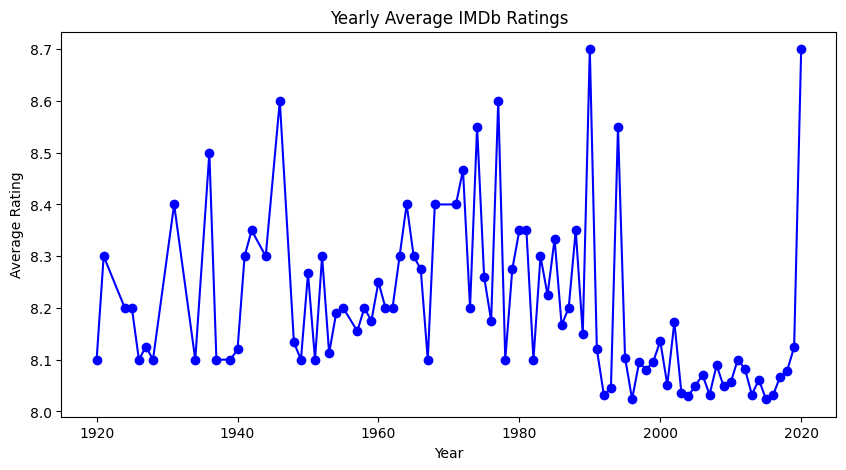

In [11]:
#5
import matplotlib.pyplot as plt
years = [int(year) for year, _ in sorted_years]
avg_ratings = [avg for _, avg in sorted_years]

plt.figure(figsize=(10, 5))
plt.plot(years, avg_ratings, marker='o', linestyle='-', color='b')
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Yearly Average IMDb Ratings")
plt.show()